   PRODUCTION QUALITY FINANCIAL REPORT
Total Batches Analyzed:       480
Cost of Corrections (Acid):   56000€
Cost of Critical Waste:       20000€
----------------------------------------
TOTAL FINANCIAL IMPACT:       76000€


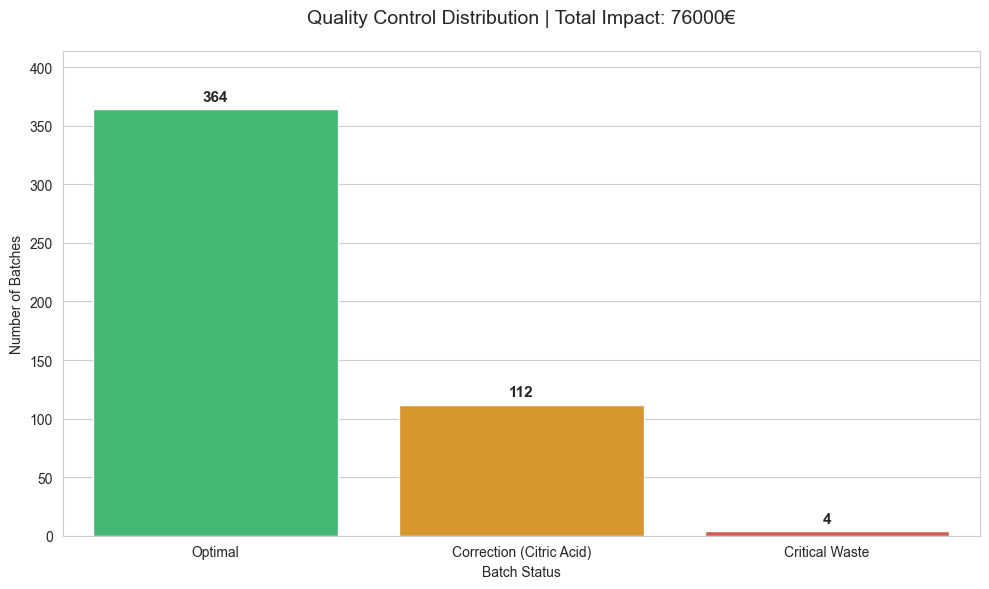

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Η συνάρτηση με τη λογική IF-ELIF-ELSE (Business Logic)
def PH_ANALYSIS(ph):
    if ph <= 4.30:
        return "Optimal", 0
    elif ph <= 4.50:
        return "Correction (Citric Acid)", 500
    else:
        return "Critical Waste", 5000

# 2. Προσομοίωση 480 μετρήσεων (8 αναλύσεις/ημέρα x 60 ημέρες)
# Χρησιμοποιούμε Normal Distribution 
np.random.seed(42)
random_ph_values = np.random.normal(loc=4.22, scale=0.12, size=480)

# 3. Δημιουργία του DataFrame
results = []
for ph in random_ph_values:
    status, loss = PH_ANALYSIS(ph)
    results.append({'pH': ph, 'Status': status, 'Loss': loss})

df = pd.DataFrame(results)

# 4. Υπολογισμοί Κόστους
waste_costs = df[df['Status'] == "Critical Waste"]['Loss'].sum()
correction_costs = df[df['Status'] == "Correction (Citric Acid)"]['Loss'].sum()
total_financial_impact = df['Loss'].sum()

# 5. Εμφάνιση Οικονομικών Αποτελεσμάτων (Terminal Output)
print("="*40)
print("   PRODUCTION QUALITY FINANCIAL REPORT")
print("="*40)
print(f"Total Batches Analyzed:       {len(df)}")
print(f"Cost of Corrections (Acid):   {correction_costs}€")
print(f"Cost of Critical Waste:       {waste_costs}€")
print("-"*40)
print(f"TOTAL FINANCIAL IMPACT:       {total_financial_impact}€")
print("="*40)

# 6. Οπτικοποίηση (Visualization)
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")

# Ορισμός χρωμάτων για κάθε κατηγορία
palette = {
    "Optimal": "#2ecc71", 
    "Correction (Citric Acid)": "#f39c12", 
    "Critical Waste": "#e74c3c"
}

# Δημιουργία Bar Chart
ax = sns.countplot(
    x='Status', 
    data=df, 
    hue='Status', 
    palette=palette, 
    order=['Optimal', 'Correction (Citric Acid)', 'Critical Waste'],
    legend=False
)

# Προσθήκη ετικετών (Labels) με τον αριθμό των παρτίδων πάνω από κάθε μπάρα
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=11,
                fontweight='bold')

# Τίτλοι και Ρυθμίσεις
plt.title(f'Quality Control Distribution | Total Impact: {total_financial_impact}€', fontsize=14, pad=20)
plt.xlabel('Batch Status')
plt.ylabel('Number of Batches')
plt.ylim(0, df['Status'].value_counts().max() + 50) # Δίνουμε χώρο για τις ετικέτες



plt.tight_layout()
plt.show()